<a href="https://colab.research.google.com/github/faaizashiq/AI_Project/blob/main/IDL_Term_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import kagglehub

dataset_base = kagglehub.dataset_download("amerzishminha/forest-fire-and-non-fire-dataset")
print("Dataset extracted to:", dataset_base)

contents = os.listdir(dataset_base)
if len(contents) == 1 and os.path.isdir(os.path.join(dataset_base, contents[0])):
    dataset_root = os.path.join(dataset_base, contents[0])
else:
    dataset_root = dataset_base

train_dir = os.path.join(dataset_root, 'train')
test_dir = os.path.join(dataset_root, 'test')

print("\n--- Download Complete ---")
print("Train path exists:", os.path.exists(train_dir))
print("Test path exists:", os.path.exists(test_dir))

100%|██████████| 3.48G/3.48G [00:34<00:00, 109MB/s] 

Extracting files...


Dataset extracted to: /root/.cache/kagglehub/datasets/amerzishminha/forest-fire-and-non-fire-dataset/versions/1

--- Download Complete ---
Train path exists: True
Test path exists: True


In [3]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("\n--- Pipeline Status: SUCCESS ---")
print(f"Detected Native Classes: {train_dataset.classes}")
print(f"Class Mapping Rules:    {train_dataset.class_to_idx}")
print(f"Total Training Images:  {len(train_dataset)}")
print(f"Total Testing Images:   {len(test_dataset)}")


--- Pipeline Status: SUCCESS ---
Detected Native Classes: ['fire', 'non fire']
Class Mapping Rules:    {'fire': 0, 'non fire': 1}
Total Training Images:  15609
Total Testing Images:   6122


In [4]:
import torch
import torch.nn as nn

class FireDetectionNet(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.4):
        super(FireDetectionNet, self).__init__()

        self.stage_1 = self._build_conv_block(in_maps=3, out_maps=32)
        self.stage_2 = self._build_conv_block(in_maps=32, out_maps=64)

        self.stage_3 = self._build_conv_block(in_maps=64, out_maps=128)
        self.stage_4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((7, 7))
        )

        self.dense_classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, num_classes)
        )

    def _build_conv_block(self, in_maps, out_maps):
        return nn.Sequential(
            nn.Conv2d(in_maps, out_maps, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(out_maps),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

    def forward(self, pixel_tensor):
        spatial_features = self.stage_1(pixel_tensor)
        spatial_features = self.stage_2(spatial_features)
        spatial_features = self.stage_3(spatial_features)
        spatial_features = self.stage_4(spatial_features)

        logits = self.dense_classifier(spatial_features)
        return logits

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = FireDetectionNet(num_classes=2).to(device)

print(f"--- CNN Architecture Initialization: COMPLETE ---")
print(f"Target Hardware Engine: [{device.type.upper()}]")

--- CNN Architecture Initialization: COMPLETE ---
Target Hardware Engine: [CUDA]


In [5]:
import torch.optim as optim
import sys

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)

def run_training_cycle(model, loader, criterion, optimizer, device, train_mode=True):
    if train_mode:
        model.train()
    else:
        model.eval()

    accumulated_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    total_batches = len(loader)

    with torch.set_grad_enabled(train_mode):
        for batch_idx, (images, targets) in enumerate(loader, 1):
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            accumulated_loss += loss.item() * images.size(0)
            _, predictions = torch.max(outputs, 1)
            total_samples += targets.size(0)
            correct_predictions += (predictions == targets).sum().item()

            if batch_idx % 5 == 0 or batch_idx == total_batches:
                current_acc = (correct_predictions / total_samples) * 100
                current_loss = accumulated_loss / total_samples
                mode_str = "TRAIN" if train_mode else "EVAL"
                sys.stdout.write(f"\r  [{mode_str}] Batch {batch_idx}/{total_batches} -> Loss: {current_loss:.4f} | Acc: {current_acc:.2f}%")
                sys.stdout.flush()

    epoch_loss = accumulated_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples
    return epoch_loss, epoch_accuracy

print("--- Optimization Engine: COMPILED ---")
print("Loss function: CrossEntropyLoss")
print("Optimizer:     AdamW")
print("Learning Rate: 0.0001")
print("Weight Decay:  0.01")

--- Optimization Engine: COMPILED ---
Loss function: CrossEntropyLoss
Optimizer:     AdamW
Learning Rate: 0.0001
Weight Decay:  0.01


In [6]:
EPOCHS = 10
best_val_acc = 0.0

print("Commencing Model Training Execution...\n")

for epoch in range(1, EPOCHS + 1):
    print(f"\n========== TRAINING CYCLE {epoch:02d} / {EPOCHS:02d} ==========")

    train_loss, train_acc = run_training_cycle(model, train_loader, criterion, optimizer, device, train_mode=True)

    val_loss, val_acc = run_training_cycle(model, test_loader, criterion, None, device, train_mode=False)
    print("")


    print(f"------------- Metrics Summary -------------")
    print(f" Final Train Performance -> Loss: {train_loss:.4f} | Accuracy: {train_acc*100:.2f}%")
    print(f" Final Valid Performance -> Loss: {val_loss:.4f} | Accuracy: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'true_binary_fire_model.pth')
        print(f" [!] System Checkpoint Saved: Peak Accuracy reached at {best_val_acc*100:.2f}%")

Commencing Model Training Execution...


========== TRAINING CYCLE 01 / 10 ==========
  [EVAL] Batch 192/192 -> Loss: 0.1842 | Acc: 92.85%
------------- Metrics Summary -------------
 Final Train Performance -> Loss: 0.2441 | Accuracy: 89.91%
 Final Valid Performance -> Loss: 0.1842 | Accuracy: 92.85%
 [!] System Checkpoint Saved: Peak Accuracy reached at 92.85%

========== TRAINING CYCLE 02 / 10 ==========
  [EVAL] Batch 192/192 -> Loss: 0.1501 | Acc: 94.63%
------------- Metrics Summary -------------
 Final Train Performance -> Loss: 0.1801 | Accuracy: 92.95%
 Final Valid Performance -> Loss: 0.1501 | Accuracy: 94.63%
 [!] System Checkpoint Saved: Peak Accuracy reached at 94.63%

========== TRAINING CYCLE 03 / 10 ==========
  [EVAL] Batch 192/192 -> Loss: 0.2370 | Acc: 90.69%
------------- Metrics Summary -------------
 Final Train Performance -> Loss: 0.1458 | Accuracy: 94.59%
 Final Valid Performance -> Loss: 0.2370 | Accuracy: 90.69%

========== TRAINING CYCLE 04 / 10 ==========
 

🔥 Best model weights successfully loaded into memory.

--- SYSTEM ONLINE: READY FOR TEST IMAGES ---


Saving forest-fire-for-kishan-img-jpg.webp to forest-fire-for-kishan-img-jpg (1).webp


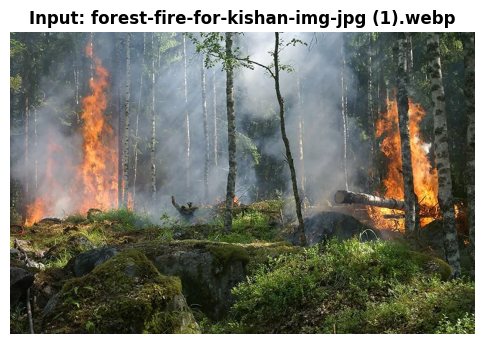


         AUTOMATED DETECTION REPORT          
Target File Name:  forest-fire-for-kishan-img-jpg (1).webp
System Prediction: FIRE (DANGER ACTIVE WARNING)
Confidence Level:  94.93%
---------------------------------------------
Full Class Probability Breakdown:
 -> FIRE (DANGER ACTIVE WARNING): 94.93%
 -> Non-Fire (Safe/Clear Landscape): 5.07%



In [9]:
import torchvision.transforms as transforms
from PIL import Image
from google.colab import files
import torch
import matplotlib.pyplot as plt

class_names = ['FIRE (DANGER ACTIVE WARNING)', 'Non-Fire (Safe/Clear Landscape)']

# Make sure 'device' is defined earlier in your notebook (e.g., device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
inference_model = FireDetectionNet(num_classes=2).to(device)

try:
    inference_model.load_state_dict(torch.load('true_binary_fire_model.pth', map_location=device))
    print("🔥 Best model weights successfully loaded into memory.")
except FileNotFoundError:
    torch.save(model.state_dict(), 'final_fallback_model.pth')
    inference_model.load_state_dict(torch.load('final_fallback_model.pth', map_location=device))
    print("⚠️ Loaded final epoch state weights.")

inference_model.eval()

# This is the defined transform name
evaluation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("\n--- SYSTEM ONLINE: READY FOR TEST IMAGES ---")
uploaded = files.upload()

for filename in uploaded.keys():
    try:
        # PIL automatically handles png, jpeg, and webp.
        # .convert('RGB') ensures any 4-channel png/webp is safely converted to 3 channels.
        raw_img = Image.open(filename).convert('RGB')

        # FIXED: Changed 'eval_transform' to 'evaluation_transform' to match the definition above
        tensor_img = evaluation_transform(raw_img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = inference_model(tensor_img)
            probabilities = torch.nn.functional.softmax(logits, dim=1)[0]

        confidence, target_class_idx = torch.max(probabilities, 0)

        plt.figure(figsize=(6, 4))
        plt.imshow(raw_img)
        plt.title(f"Input: {filename}", fontsize=12, fontweight='bold')
        plt.axis('off')
        plt.show()

        print("\n=============================================")
        print("         AUTOMATED DETECTION REPORT          ")
        print("=============================================")
        print(f"Target File Name:  {filename}")
        print(f"System Prediction: {class_names[target_class_idx]}")
        print(f"Confidence Level:  {confidence.item() * 100:.2f}%")
        print("---------------------------------------------")
        print("Full Class Probability Breakdown:")
        for idx, name in enumerate(class_names):
            print(f" -> {name}: {probabilities[idx].item() * 100:.2f}%")
        print("=============================================\n")

    except Exception as e:
        print(f"Error handling file processing for {filename}: {e}")

🔥 Best model weights successfully loaded into memory.

--- SYSTEM ONLINE: READY FOR TEST IMAGES ---


Saving images (1).jpeg to images (1) (1).jpeg


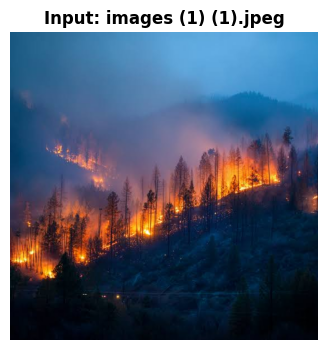


         AUTOMATED DETECTION REPORT          
Target File Name:  images (1) (1).jpeg
System Prediction: FIRE (DANGER ACTIVE WARNING)
Confidence Level:  100.00%
---------------------------------------------
Full Class Probability Breakdown:
 -> FIRE (DANGER ACTIVE WARNING): 100.00%
 -> Non-Fire (Safe/Clear Landscape): 0.00%



In [10]:
import torchvision.transforms as transforms
from PIL import Image
from google.colab import files
import torch
import matplotlib.pyplot as plt

class_names = ['FIRE (DANGER ACTIVE WARNING)', 'Non-Fire (Safe/Clear Landscape)']

# Make sure 'device' is defined earlier in your notebook (e.g., device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
inference_model = FireDetectionNet(num_classes=2).to(device)

try:
    inference_model.load_state_dict(torch.load('true_binary_fire_model.pth', map_location=device))
    print("🔥 Best model weights successfully loaded into memory.")
except FileNotFoundError:
    torch.save(model.state_dict(), 'final_fallback_model.pth')
    inference_model.load_state_dict(torch.load('final_fallback_model.pth', map_location=device))
    print("⚠️ Loaded final epoch state weights.")

inference_model.eval()

# This is the defined transform name
evaluation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("\n--- SYSTEM ONLINE: READY FOR TEST IMAGES ---")
uploaded = files.upload()

for filename in uploaded.keys():
    try:
        # PIL automatically handles png, jpeg, and webp.
        # .convert('RGB') ensures any 4-channel png/webp is safely converted to 3 channels.
        raw_img = Image.open(filename).convert('RGB')

        # FIXED: Changed 'eval_transform' to 'evaluation_transform' to match the definition above
        tensor_img = evaluation_transform(raw_img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = inference_model(tensor_img)
            probabilities = torch.nn.functional.softmax(logits, dim=1)[0]

        confidence, target_class_idx = torch.max(probabilities, 0)

        plt.figure(figsize=(6, 4))
        plt.imshow(raw_img)
        plt.title(f"Input: {filename}", fontsize=12, fontweight='bold')
        plt.axis('off')
        plt.show()

        print("\n=============================================")
        print("         AUTOMATED DETECTION REPORT          ")
        print("=============================================")
        print(f"Target File Name:  {filename}")
        print(f"System Prediction: {class_names[target_class_idx]}")
        print(f"Confidence Level:  {confidence.item() * 100:.2f}%")
        print("---------------------------------------------")
        print("Full Class Probability Breakdown:")
        for idx, name in enumerate(class_names):
            print(f" -> {name}: {probabilities[idx].item() * 100:.2f}%")
        print("=============================================\n")

    except Exception as e:
        print(f"Error handling file processing for {filename}: {e}")

🔥 Best model weights successfully loaded into memory.

--- SYSTEM ONLINE: READY FOR TEST IMAGES ---


Saving images.jpeg to images.jpeg


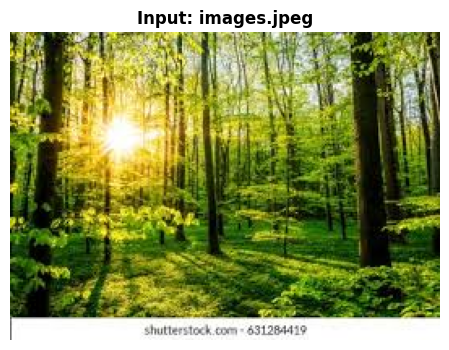


         AUTOMATED DETECTION REPORT          
Target File Name:  images.jpeg
System Prediction: Non-Fire (Safe/Clear Landscape)
Confidence Level:  100.00%
---------------------------------------------
Full Class Probability Breakdown:
 -> FIRE (DANGER ACTIVE WARNING): 0.00%
 -> Non-Fire (Safe/Clear Landscape): 100.00%



In [11]:
import torchvision.transforms as transforms
from PIL import Image
from google.colab import files
import torch
import matplotlib.pyplot as plt

class_names = ['FIRE (DANGER ACTIVE WARNING)', 'Non-Fire (Safe/Clear Landscape)']

# Make sure 'device' is defined earlier in your notebook (e.g., device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
inference_model = FireDetectionNet(num_classes=2).to(device)

try:
    inference_model.load_state_dict(torch.load('true_binary_fire_model.pth', map_location=device))
    print("🔥 Best model weights successfully loaded into memory.")
except FileNotFoundError:
    torch.save(model.state_dict(), 'final_fallback_model.pth')
    inference_model.load_state_dict(torch.load('final_fallback_model.pth', map_location=device))
    print("⚠️ Loaded final epoch state weights.")

inference_model.eval()

# This is the defined transform name
evaluation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("\n--- SYSTEM ONLINE: READY FOR TEST IMAGES ---")
uploaded = files.upload()

for filename in uploaded.keys():
    try:
        # PIL automatically handles png, jpeg, and webp.
        # .convert('RGB') ensures any 4-channel png/webp is safely converted to 3 channels.
        raw_img = Image.open(filename).convert('RGB')

        # FIXED: Changed 'eval_transform' to 'evaluation_transform' to match the definition above
        tensor_img = evaluation_transform(raw_img).unsqueeze(0).to(device)

        with torch.no_grad():
            logits = inference_model(tensor_img)
            probabilities = torch.nn.functional.softmax(logits, dim=1)[0]

        confidence, target_class_idx = torch.max(probabilities, 0)

        plt.figure(figsize=(6, 4))
        plt.imshow(raw_img)
        plt.title(f"Input: {filename}", fontsize=12, fontweight='bold')
        plt.axis('off')
        plt.show()

        print("\n=============================================")
        print("         AUTOMATED DETECTION REPORT          ")
        print("=============================================")
        print(f"Target File Name:  {filename}")
        print(f"System Prediction: {class_names[target_class_idx]}")
        print(f"Confidence Level:  {confidence.item() * 100:.2f}%")
        print("---------------------------------------------")
        print("Full Class Probability Breakdown:")
        for idx, name in enumerate(class_names):
            print(f" -> {name}: {probabilities[idx].item() * 100:.2f}%")
        print("=============================================\n")

    except Exception as e:
        print(f"Error handling file processing for {filename}: {e}")